# Sequential Pipeline Inference — MACS → DeiT (trained on raw)

Notebook này chạy **cấu hình Sequential**: raw MRI đi qua MACS-Net trước, sau đó đưa vào DeiT đã được **train trên raw images**.

Mục đích: so sánh với 2 cấu hình còn lại:

| Cấu hình | Train DeiT | Inference |
|---|---|---|
| **Baseline** | Raw | Raw (không qua MACS) |
| **Sequential** ← notebook này | Raw | MACS → cleaned → DeiT |
| **Online (proposed)** | Cleaned (MACS on-the-fly) | Cleaned |

> ⚠️ Sequential có thể bị **distribution shift** vì DeiT train trên raw nhưng inference nhận cleaned input.

## Cell 0 — Mount Drive (Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1 — Cài thư viện

In [ ]:
!pip -q install timm nibabel scikit-learn tqdm opencv-python-headless monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 48.4 MB/s eta 0:00:00


## Cell 2 — Imports

In [ ]:
import os, re, json, math, random, gc, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import MultiLabelBinarizer

import timm
from monai.networks.nets import SwinUNETR

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## Cell 3 — Config

> **📌 Cập nhật các đường dẫn này trước khi chạy:**
> - `MACS_CHECKPOINT_PATH` — checkpoint MACS đã train
> - `BASELINE_DEIT_CHECKPOINT_PATH` — checkpoint DeiT **train trên raw** (baseline)
> - `ONLINE_RESULTS_CSV` — file `summary_metrics.csv` từ notebook online (để so sánh)
> - `BASELINE_RESULTS_CSV` — file `summary_metrics.csv` từ notebook baseline

In [ ]:
# ================================================================
# ⚠️  CẬP NHẬT CÁC ĐƯỜNG DẪN NÀY TRƯỚC KHI CHẠY
# ================================================================

# MACS checkpoint (output của MACS_Net_KMAR_Local notebook)
MACS_CHECKPOINT_PATH = "/content/drive/MyDrive/best_macs_net.pth"

# DeiT checkpoint đã train trên RAW (baseline — USE_MACS_CLEANING=False)
BASELINE_DEIT_CHECKPOINT_PATH = "/content/drive/MyDrive/SKM-TEA/cleaned_outputs/main_raw_deit_small_t4_fast_antioverfit/checkpoints/best_deit_small_multilabel_main.pth"

# Kết quả từ 2 cấu hình kia (để so sánh cuối notebook)
# Nếu chưa có thì để None
ONLINE_RESULTS_CSV   = "/content/drive/MyDrive/SKM-TEA/cleaned_outputs/main_macs_deit_small_t4_proposed/reports/summary_metrics.csv"
BASELINE_RESULTS_CSV = "/content/drive/MyDrive/SKM-TEA/cleaned_outputs/main_raw_deit_small_t4_fast_antioverfit/reports/summary_metrics.csv"   # đường dẫn tới summary_metrics.csv của baseline nếu có

# SKM-TEA paths — giống hệt notebook online
SKM_ROOT      = "/content/drive/MyDrive/SKM-TEA"
MANIFEST_PATH = "/content/drive/MyDrive/SKM-TEA/cleaned_outputs/manifests/stage3_base_manifest.csv"
TRAIN_JSON    = "/content/drive/MyDrive/SKM-TEA/annotations/train.json"
VAL_JSON      = "/content/drive/MyDrive/SKM-TEA/annotations/val.json"
TEST_JSON     = "/content/drive/MyDrive/SKM-TEA/annotations/test.json"

# ================================================================
# Pipeline settings
# ================================================================
MACS_IMG_SIZE = 128      # phải khớp với IMG_SIZE lúc train MACS
DEIT_IMG_SIZE = 224      # DeiT input size

EXPERIMENT_NAME = "sequential_macs_deit_raw"
OUTPUT_ROOT  = f"/content/drive/MyDrive/SKM-TEA/cleaned_outputs/{EXPERIMENT_NAME}"
REPORT_DIR   = f"{OUTPUT_ROOT}/reports"
CACHE_DIR    = f"{OUTPUT_ROOT}/cache"
for d in [OUTPUT_ROOT, REPORT_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

# Inference settings — giữ nguyên như notebook online để so sánh fair
BATCH_SIZE   = 4
NUM_WORKERS  = 0
PIN_MEMORY   = torch.cuda.is_available()
USE_AMP      = torch.cuda.is_available()
AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"
AGG_METHOD   = "max"

SLICE_START_FRAC = 0.15
SLICE_END_FRAC   = 0.85
MAX_SAMPLES_PER_STUDY_EVAL = 12
MIN_FOREGROUND_RATIO = 0.01
CACHE_MAX_VOLUMES_EVAL = 2

DROPOUT_RATE   = 0.25
DROP_PATH_RATE = 0.15

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_CHANNELS_LAST = torch.cuda.is_available()

print('DEVICE:', DEVICE)
print('EXPERIMENT_NAME:', EXPERIMENT_NAME)
print('MACS_CHECKPOINT_PATH:', MACS_CHECKPOINT_PATH)
print('BASELINE_DEIT_CHECKPOINT_PATH:', BASELINE_DEIT_CHECKPOINT_PATH)

DEVICE: cuda
EXPERIMENT_NAME: sequential_macs_deit_raw
MACS_CHECKPOINT_PATH: /content/drive/MyDrive/best_macs_net.pth
BASELINE_DEIT_CHECKPOINT_PATH: /content/drive/MyDrive/SKM-TEA/cleaned_outputs/main_raw_deit_small_t4_fast_antioverfit/checkpoints/best_deit_small_multilabel_main.pth


## Cell 4 — Seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)

## Cell 5 — Load MACS-Net checkpoint (frozen)

MACS chạy ở **eval/frozen mode** — giống hệt notebook online.

In [ ]:
macs_model = SwinUNETR(
    in_channels=1, out_channels=1, feature_size=24, spatial_dims=2
).to(DEVICE)

if not os.path.exists(MACS_CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy MACS checkpoint:\n  {MACS_CHECKPOINT_PATH}\n"
        "Hãy cập nhật MACS_CHECKPOINT_PATH trong Cell 3."
    )

_ckpt = torch.load(MACS_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
if isinstance(_ckpt, dict) and "model_state_dict" in _ckpt:
    macs_model.load_state_dict(_ckpt["model_state_dict"])
    print(f"Loaded MACS checkpoint (epoch={_ckpt.get('epoch','?')}, "
          f"val_loss={_ckpt.get('val_loss', float('nan')):.6f})")
else:
    macs_model.load_state_dict(_ckpt)
    print("Loaded MACS state_dict (plain format).")

macs_model.eval()
for p in macs_model.parameters():
    p.requires_grad = False
print("MACS-Net ready (frozen, eval mode).")


@torch.no_grad()
def macs_clean_slice(slice_np: np.ndarray) -> np.ndarray:
    """Clean 1 raw MRI slice qua MACS-Net.
    Input : 2D numpy (H,W), raw intensity
    Output: 2D numpy (H,W), cleaned, giá trị trong [0,1]
    """
    h_orig, w_orig = slice_np.shape
    arr = slice_np.astype(np.float32)
    lo, hi = arr.min(), arr.max()
    if hi - lo < 1e-8:
        return np.zeros((h_orig, w_orig), dtype=np.float32)
    arr = (arr - lo) / (hi - lo)

    if arr.shape != (MACS_IMG_SIZE, MACS_IMG_SIZE):
        t = torch.tensor(arr).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=(MACS_IMG_SIZE, MACS_IMG_SIZE),
                          mode='bilinear', align_corners=False)
        arr = t.squeeze().numpy()

    x = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.amp.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
        cleaned = macs_model(x)
    cleaned = np.clip(cleaned.squeeze().float().cpu().numpy(), 0.0, 1.0)

    if (h_orig, w_orig) != (MACS_IMG_SIZE, MACS_IMG_SIZE):
        t = torch.tensor(cleaned).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=(h_orig, w_orig),
                          mode='bilinear', align_corners=False)
        cleaned = t.squeeze().numpy()
    return cleaned.astype(np.float32)

print("macs_clean_slice() defined.")

Loaded MACS checkpoint (epoch=20, val_loss=0.029343)
MACS-Net ready (frozen, eval mode).
macs_clean_slice() defined.


## Cell 6 — Load DeiT baseline checkpoint (trained on raw)

Đây là DeiT đã train với `USE_MACS_CLEANING=False`. Model này **không biết** cleaned images là gì — đây chính là điểm tạo ra distribution shift.

In [ ]:
# ── Đọc annotation JSON để lấy category info ──────────────────────────────────
with open(TRAIN_JSON) as f: train_ann = json.load(f)
categories = pd.DataFrame(train_ann["categories"]).sort_values("id").reset_index(drop=True)
cat_id_to_name = dict(zip(categories["id"], categories["name"]))
category_ids   = categories["id"].tolist()
category_names = categories["name"].tolist()
label_cols     = [f"cat_{cid}" for cid in category_ids]
print("Num categories:", len(category_ids))
print("Categories:", category_names)

# ── Build DeiT model ──────────────────────────────────────────────────────────
deit_model = timm.create_model(
    "deit_small_patch16_224", pretrained=False,
    num_classes=len(label_cols),
    drop_rate=DROPOUT_RATE,
    drop_path_rate=DROP_PATH_RATE
).to(DEVICE)

if USE_CHANNELS_LAST and torch.cuda.is_available():
    deit_model = deit_model.to(memory_format=torch.channels_last)

if not os.path.exists(BASELINE_DEIT_CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy DeiT baseline checkpoint:\n  {BASELINE_DEIT_CHECKPOINT_PATH}\n"
        "Hãy cập nhật BASELINE_DEIT_CHECKPOINT_PATH trong Cell 3."
    )

def torch_load(path):
    try: return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError: return torch.load(path, map_location=DEVICE)

ck = torch_load(BASELINE_DEIT_CHECKPOINT_PATH)
state = ck["model_state"] if "model_state" in ck else ck
deit_model.load_state_dict(state)
print(f"Loaded DeiT baseline checkpoint (epoch={ck.get('epoch','?')})")
print(f"Checkpoint config: {ck.get('config', 'N/A')}")
deit_model.eval()
print("DeiT baseline ready (eval mode).")

Num categories: 16
Categories: ['Meniscal Tear (Myxoid)', 'Meniscal Tear (Horizontal)', 'Meniscal Tear (Radial)', 'Meniscal Tear (Vertical/Longitudinal)', 'Meniscal Tear (Oblique)', 'Meniscal Tear (Complex)', 'Meniscal Tear (Flap)', 'Meniscal Tear (Extrusion)', 'Ligament Tear (Low-Grade Sprain)', 'Ligament Tear (Moderate Grade Sprain or Mucoid Degeneration)', 'Ligament Tear (Full Thickness/Complete Tear)', 'Cartilage Lesion (1)', 'Cartilage Lesion (2A)', 'Cartilage Lesion (2B)', 'Cartilage Lesion (3)', 'Effusion']
Loaded DeiT baseline checkpoint (epoch=27)
Checkpoint config: {'IMG_SIZE': 224, 'BATCH_SIZE': 4, 'ACCUM_STEPS': 2, 'EPOCHS': 30, 'LR': 5e-05, 'BACKBONE_LR_MULT': 0.2, 'WEIGHT_DECAY': 0.001, 'USE_CLEANED': False, 'SAVE_EVERY_EPOCHS': 8, 'AGG_METHOD': 'max', 'DROPOUT_RATE': 0.25, 'DROP_PATH_RATE': 0.15, 'LABEL_SMOOTHING': 0.01, 'POS_WEIGHT_MAX': 5.0, 'FREEZE_LOWER_BACKBONE': True, 'FREEZE_NUM_BLOCKS': 6, 'MAX_SAMPLES_PER_STUDY_TRAIN': 8, 'MAX_SAMPLES_PER_STUDY_EVAL': 12}
DeiT b

## Cell 7 — Utility functions

In [ ]:
def load_nifti_volume(path):
    if not isinstance(path, str) or not os.path.exists(path):
        raise FileNotFoundError(f"NIfTI không tồn tại: {path}")
    img = nib.load(path)
    try:
        vol = img.get_fdata(dtype=np.float32, caching="unchanged")
    except TypeError:
        vol = np.asarray(img.dataobj, dtype=np.float32)
    return np.asarray(vol, dtype=np.float32)

def percentile_normalize(x, p1=1, p99=99):
    x = x.astype(np.float32, copy=False)
    lo, hi = np.percentile(x, p1), np.percentile(x, p99)
    if hi <= lo:
        mn, mx = x.min(), x.max()
        return ((x-mn)/(mx-mn+1e-8)).astype(np.float32)
    return np.clip((x-lo)/(hi-lo), 0, 1).astype(np.float32)

def resize_2d(img, out_size=224):
    return cv2.resize(img, (out_size,out_size), interpolation=cv2.INTER_AREA).astype(np.float32)

def get_candidate_slice_indices(vol, start_frac=0.2, end_frac=0.8, min_fg_ratio=0.01):
    if vol.ndim != 3 or vol.shape[-1] < 3: return []
    d = vol.shape[-1]
    z0, z1 = max(1, int(d*start_frac)), min(d-2, int(d*end_frac))
    idxs = [z for z in range(z0,z1) if np.mean(vol[...,z] > vol[...,z].mean()) >= min_fg_ratio]
    return idxs or list(range(max(1,d//4), min(d-2,3*d//4)))

def sample_slice_indices(idxs, max_samples):
    idxs = list(idxs)
    if len(idxs) <= max_samples: return idxs
    return [idxs[i] for i in np.linspace(0, len(idxs)-1, max_samples).astype(int)]

print("Utility functions defined.")

Utility functions defined.


## Cell 8 — Đọc annotations và build label dataframe

In [ ]:
with open(VAL_JSON)  as f: val_ann  = json.load(f)
with open(TEST_JSON) as f: test_ann = json.load(f)
print("val :", len(val_ann["images"]),  len(val_ann["annotations"]))
print("test:", len(test_ann["images"]), len(test_ann["annotations"]))

mlb = MultiLabelBinarizer(classes=category_ids)

def build_split_labels(json_obj, split_name):
    images_df = pd.DataFrame(json_obj["images"]).copy()
    ann_df    = pd.DataFrame(json_obj["annotations"]).copy()
    img_to_scan = dict(zip(images_df["id"], images_df["scan_id"]))
    ann_df["scan_id"] = ann_df["image_id"].map(img_to_scan)
    ann_df = ann_df[ann_df["category_id"].isin(category_ids)].copy()
    grouped = ann_df.groupby("scan_id")["category_id"].apply(
        lambda x: sorted(set(x.tolist()))).reset_index()
    grouped["split"] = split_name
    all_scans = images_df["scan_id"].dropna().unique().tolist()
    grouped = pd.DataFrame({"scan_id": all_scans}).merge(grouped, on="scan_id", how="left")
    grouped["category_id"] = grouped["category_id"].apply(
        lambda x: x if isinstance(x, list) else [])
    grouped["split"] = split_name
    meta_cols = ["scan_id","subject_id","timepoint","inspected",
                 "matrix_shape","orientation","voxel_spacing"]
    meta_cols = [c for c in meta_cols if c in images_df.columns]
    meta_df = images_df[meta_cols].drop_duplicates("scan_id")
    return grouped.merge(meta_df, on="scan_id", how="left")

val_labels  = build_split_labels(val_ann,  "val")
test_labels = build_split_labels(test_ann, "test")
labels_df   = pd.concat([val_labels, test_labels], ignore_index=True)

Y = mlb.fit_transform(labels_df["category_id"])
multi_label_df = pd.DataFrame(Y, columns=label_cols)
multi_label_df["scan_id"] = labels_df["scan_id"].values
multi_label_df["split"]   = labels_df["split"].values
labels_df = labels_df.merge(multi_label_df, on=["scan_id","split"], how="left")
labels_df["num_positive_labels"] = Y.sum(axis=1)
print("Labels built:", labels_df.shape)

val : 33 104
test: 36 130
Labels built: (69, 26)


## Cell 9 — Load manifest và merge

In [ ]:
base_df = pd.read_csv(MANIFEST_PATH)
base_df["scan_id"] = base_df["mtr_id"].astype(str).str.strip()

candidate_raw_cols = ["raw_nii_path","nii_raw_path","raw_path","nii_path"]
raw_col = next((c for c in candidate_raw_cols if c in base_df.columns), None)
if raw_col is None:
    raise ValueError(f"Manifest không có cột raw path. Có: {base_df.columns.tolist()}")
image_col = raw_col
print("Using image_col =", image_col)

base_df[image_col] = base_df[image_col].astype(str).str.strip()
base_df = base_df[base_df[image_col] != ""].copy()

dataset_df = base_df.merge(labels_df, on="scan_id", how="inner").copy()
dataset_df = dataset_df[
    dataset_df[image_col].apply(lambda p: isinstance(p,str) and os.path.exists(p))
].copy()

val_df  = dataset_df[dataset_df["split"]=="val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["split"]=="test"].reset_index(drop=True)
print(f"val: {val_df.shape} | test: {test_df.shape}")
display(test_df[["scan_id", image_col, "split", "num_positive_labels"]].head())

Using image_col = raw_nii_path
val: (33, 34) | test: (36, 34)


,scan_id,raw_nii_path,split,num_positive_labels
0,MTR_005,/content/drive/MyDrive/SKM-TEA/cleaned_outputs...,test,2
1,MTR_006,/content/drive/MyDrive/SKM-TEA/cleaned_outputs...,test,4
2,MTR_030,/content/drive/MyDrive/SKM-TEA/cleaned_outputs...,test,7
3,MTR_034,/content/drive/MyDrive/SKM-TEA/cleaned_outputs...,test,2
4,MTR_048,/content/drive/MyDrive/SKM-TEA/cleaned_outputs...,test,1


## Cell 10 — Build sample table (test + val)

Dùng cache để tránh re-index mỗi lần chạy.

In [ ]:
sample_cache_key = hashlib.md5(
    f"sequential|{image_col}|{SLICE_START_FRAC}|{SLICE_END_FRAC}"
    f"|{MIN_FOREGROUND_RATIO}|{MAX_SAMPLES_PER_STUDY_EVAL}".encode()
).hexdigest()[:10]

val_sample_cache  = os.path.join(CACHE_DIR, f"val_{sample_cache_key}.csv")
test_sample_cache = os.path.join(CACHE_DIR, f"test_{sample_cache_key}.csv")

def build_sample_table(df, max_per_study):
    rows, skipped = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Building samples"):
        path = row[image_col]
        try:
            vol = load_nifti_volume(path)
        except Exception as e:
            skipped.append((row.get("scan_id","?"), str(e))); continue
        if vol.ndim != 3:
            skipped.append((row.get("scan_id","?"), f"ndim={vol.ndim}")); continue
        idxs = sample_slice_indices(
            get_candidate_slice_indices(vol, SLICE_START_FRAC, SLICE_END_FRAC, MIN_FOREGROUND_RATIO),
            max_per_study)
        for z in idxs:
            sample = {"scan_id":row["scan_id"],"image_path":path,"slice_idx":int(z),"split":row["split"]}
            for c in label_cols: sample[c] = int(row[c])
            rows.append(sample)
        del vol
    if skipped: print(f"Warning: skipped {len(skipped)} studies")
    return pd.DataFrame(rows)

def load_or_build_samples(df, max_per, cache, name):
    if os.path.exists(cache):
        try:
            out = pd.read_csv(cache)
            if len(out) > 0:
                print(f"Loaded cached {name}:", cache, out.shape)
                return out
        except Exception as e:
            print(f"Cache lỗi ({e}), rebuild {name}...")
    tmp = cache + ".tmp"
    out = build_sample_table(df, max_per)
    out.to_csv(tmp, index=False)
    os.replace(tmp, cache)
    print(f"Saved {name}:", cache, out.shape)
    return out

val_samples  = load_or_build_samples(val_df,  MAX_SAMPLES_PER_STUDY_EVAL, val_sample_cache,  "val")
test_samples = load_or_build_samples(test_df, MAX_SAMPLES_PER_STUDY_EVAL, test_sample_cache, "test")
print(f"val: {val_samples.shape} | test: {test_samples.shape}")

Building samples:   0%|          | 0/33 [00:00<?, ?it/s]

Saved val: /content/drive/MyDrive/SKM-TEA/cleaned_outputs/sequential_macs_deit_raw/cache/val_240ae12948.csv (396, 20)


Building samples:   0%|          | 0/36 [00:00<?, ?it/s]

Saved test: /content/drive/MyDrive/SKM-TEA/cleaned_outputs/sequential_macs_deit_raw/cache/test_240ae12948.csv (432, 20)
val: (396, 20) | test: (432, 20)


## Cell 11 — Sequential Dataset

**Điểm khác biệt cốt lõi so với notebook online:**
- Online: `macs_clean_slice()` gọi trong dataset của DeiT đã train trên cleaned
- Sequential: `macs_clean_slice()` gọi trong dataset của DeiT đã train trên **raw**

Code `_process_slice()` trông giống nhau nhưng model DeiT nhận input khác với lúc train → distribution shift.

In [ ]:
class SequentialInferenceDataset(Dataset):
    """
    Dataset cho cấu hình Sequential:
      raw slice → MACS clean → resize 224×224
      × 3 slices (z-1, z, z+1) → tensor (3, 224, 224)

    DeiT nhận input đã cleaned nhưng đã được train trên raw.
    """
    def __init__(self, samples_df, img_size=224, cache_max_volumes=0):
        self.df = samples_df.reset_index(drop=True)
        self.img_size = img_size
        self.cache_max_volumes = int(cache_max_volumes)
        self.cache = {}
        self.cache_order = []

    def __len__(self):
        return len(self.df)

    def _load_vol(self, path):
        if self.cache_max_volumes <= 0:
            return load_nifti_volume(path)
        if path in self.cache:
            return self.cache[path]
        vol = load_nifti_volume(path)
        self.cache[path] = vol
        self.cache_order.append(path)
        while len(self.cache_order) > self.cache_max_volumes:
            self.cache.pop(self.cache_order.pop(0), None)
        return vol

    def _process_slice(self, vol, z):
        """Sequential: raw slice → MACS clean → resize.
        DeiT train trên raw nhưng nhận cleaned → distribution shift.
        """
        sl = vol[..., z].astype(np.float32)
        sl = macs_clean_slice(sl)          # ← MACS clean (distribution shift!)
        return resize_2d(sl, self.img_size)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = row["image_path"]
        z    = int(row["slice_idx"])
        vol  = self._load_vol(path)
        depth = vol.shape[-1]

        chs = [self._process_slice(vol, max(0,z-1)),
               self._process_slice(vol, z),
               self._process_slice(vol, min(depth-1,z+1))]
        x = np.stack(chs, axis=0).astype(np.float32)  # (3,H,W)

        y = row[label_cols].values.astype(np.float32)
        return {
            "image":     torch.from_numpy(x.copy()).float(),
            "target":    torch.tensor(y, dtype=torch.float32),
            "scan_id":   row["scan_id"],
            "slice_idx": z,
        }

print("SequentialInferenceDataset defined.")

SequentialInferenceDataset defined.


## Cell 12 — DataLoaders

In [ ]:
val_ds  = SequentialInferenceDataset(val_samples,  DEIT_IMG_SIZE, cache_max_volumes=CACHE_MAX_VOLUMES_EVAL)
test_ds = SequentialInferenceDataset(test_samples, DEIT_IMG_SIZE, cache_max_volumes=CACHE_MAX_VOLUMES_EVAL)

val_loader  = DataLoader(val_ds,  BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"val: {len(val_ds)} slices | test: {len(test_ds)} slices")

# Smoke test
batch = next(iter(val_loader))
print("images:", batch["image"].shape, batch["image"].dtype)
print("targets:", batch["target"].shape)
assert batch["image"].ndim == 4 and batch["image"].shape[1] == 3
print("Smoke test PASSED ✓")

val: 396 slices | test: 432 slices
images: torch.Size([4, 3, 224, 224]) torch.float32
targets: torch.Size([4, 16])
Smoke test PASSED ✓


## Cell 13 — Inference & metric helpers

In [ ]:
criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def infer_loader(model, loader):
    model.eval()
    all_rows = []; total_loss = 0.0
    for batch in tqdm(loader, desc="Inferring", leave=False):
        x = batch["image"].to(DEVICE, non_blocking=True)
        if USE_CHANNELS_LAST and x.ndim == 4:
            x = x.contiguous(memory_format=torch.channels_last)
        y = batch["target"].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
            logits = model(x)
            loss   = criterion(logits, y)
        probs      = torch.sigmoid(logits).float().cpu().numpy()
        y_np       = y.float().cpu().numpy()
        logits_cpu = logits.float().cpu().numpy()
        total_loss += loss.item() * x.size(0)
        for i in range(x.size(0)):
            row = {"scan_id": batch["scan_id"][i], "slice_idx": int(batch["slice_idx"][i])}
            for j, c in enumerate(label_cols):
                row[f"logit_{c}"] = float(logits_cpu[i, j])
                row[f"prob_{c}"]  = float(probs[i, j])
                row[f"true_{c}"]  = float(y_np[i, j])
            all_rows.append(row)
    return total_loss / len(loader.dataset), pd.DataFrame(all_rows)

def aggregate_to_study(pred_df, method="max"):
    prob_cols = [c for c in pred_df.columns if c.startswith("prob_cat_")]
    true_cols = [c for c in pred_df.columns if c.startswith("true_cat_")]
    agg_p = (pred_df.groupby("scan_id")[prob_cols].max() if method == "max"
             else pred_df.groupby("scan_id")[prob_cols].mean()).reset_index()
    agg_t = pred_df.groupby("scan_id")[true_cols].max().reset_index()
    return agg_p.merge(agg_t, on="scan_id", how="inner")

def safe_multilabel_auc(y_true, y_prob):
    aucs, valid = {}, []
    for i, cid in enumerate(category_ids):
        if len(np.unique(y_true[:, i])) < 2: aucs[cid] = np.nan; continue
        aucs[cid] = roc_auc_score(y_true[:, i], y_prob[:, i]); valid.append(aucs[cid])
    return (float(np.nanmean(valid)) if valid else np.nan), aucs

def compute_study_metrics(study_df, threshold=0.5):
    prob_cols = [f"prob_cat_{cid}" for cid in category_ids]
    true_cols = [f"true_cat_{cid}" for cid in category_ids]
    y_prob = study_df[prob_cols].values
    y_true = (study_df[true_cols].values >= 0.5).astype(int)
    y_pred = (y_prob >= threshold).astype(int)
    macro_auc, aucs = safe_multilabel_auc(y_true, y_prob)
    return {
        "macro_auc":        macro_auc,
        "micro_f1":         f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_precision":  precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall":     recall_score(y_true, y_pred, average="micro", zero_division=0),
    }, aucs

def find_best_threshold(study_df, thresholds=None):
    thresholds = thresholds or np.arange(0.10, 0.91, 0.05)
    prob_cols  = [f"prob_cat_{cid}" for cid in category_ids]
    true_cols  = [f"true_cat_{cid}" for cid in category_ids]
    y_prob = study_df[prob_cols].values
    y_true = (study_df[true_cols].values >= 0.5).astype(int)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob >= float(t)).astype(int), average="micro", zero_division=0)
        if f1 > best_f1: best_t, best_f1 = float(t), float(f1)
    return best_t, best_f1

print("Inference & metric helpers defined.")

Inference & metric helpers defined.


## Cell 14 — Chạy inference Sequential trên val + test

In [ ]:
print("=" * 60)
print("Running SEQUENTIAL inference (MACS → DeiT trained on raw)")
print("=" * 60)

# Val
val_loss, val_pred_df = infer_loader(deit_model, val_loader)
val_study_df  = aggregate_to_study(val_pred_df, AGG_METHOD)
BEST_THRESHOLD, _ = find_best_threshold(val_study_df)
val_metrics, val_aucs = compute_study_metrics(val_study_df, BEST_THRESHOLD)
print(f"\n[VAL] threshold={BEST_THRESHOLD:.2f} | loss={val_loss:.6f}")
print(val_metrics)

# Test
test_loss, test_pred_df = infer_loader(deit_model, test_loader)
test_study_df = aggregate_to_study(test_pred_df, AGG_METHOD)
test_metrics, test_aucs = compute_study_metrics(test_study_df, BEST_THRESHOLD)
print(f"\n[TEST] threshold={BEST_THRESHOLD:.2f} (from val) | loss={test_loss:.6f}")
print(test_metrics)

# Save predictions
val_pred_df.to_csv(os.path.join(REPORT_DIR, "val_slice_predictions.csv"), index=False)
val_study_df.to_csv(os.path.join(REPORT_DIR, "val_study_predictions.csv"), index=False)
test_pred_df.to_csv(os.path.join(REPORT_DIR, "test_slice_predictions.csv"), index=False)
test_study_df.to_csv(os.path.join(REPORT_DIR, "test_study_predictions.csv"), index=False)

# Save summary
seq_summary = pd.DataFrame([
    {"split":"val",  "config":"sequential", "loss":val_loss,  "threshold":BEST_THRESHOLD, **val_metrics},
    {"split":"test", "config":"sequential", "loss":test_loss, "threshold":BEST_THRESHOLD, **test_metrics},
])
seq_summary.to_csv(os.path.join(REPORT_DIR, "summary_metrics.csv"), index=False)
display(seq_summary)

Running SEQUENTIAL inference (MACS → DeiT trained on raw)


Inferring:   0%|          | 0/99 [00:00<?, ?it/s]


[VAL] threshold=0.45 | loss=0.423464
{'macro_auc': 0.6557449684700772, 'micro_f1': 0.4555984555984556, 'macro_f1': 0.2644790726461591, 'micro_precision': 0.3333333333333333, 'micro_recall': 0.7195121951219512}


Inferring:   0%|          | 0/108 [00:00<?, ?it/s]


[TEST] threshold=0.45 (from val) | loss=0.445536
{'macro_auc': 0.6042306905273228, 'micro_f1': 0.5050505050505051, 'macro_f1': 0.2284358261419432, 'micro_precision': 0.4032258064516129, 'micro_recall': 0.6756756756756757}


,split,config,loss,threshold,macro_auc,micro_f1,macro_f1,micro_precision,micro_recall
0,val,sequential,0.423464,0.45,0.655745,0.455598,0.264479,0.333333,0.719512
1,test,sequential,0.445536,0.45,0.604231,0.505051,0.228436,0.403226,0.675676


## Cell 15 — So sánh 3 cấu hình

Load kết quả từ notebook Baseline và Online để so sánh trực tiếp.

In [ ]:
all_configs = []

# Sequential (vừa chạy)
for _, row in seq_summary.iterrows():
    all_configs.append({
        "config": "Sequential\n(MACS→DeiT_raw)",
        "split": row["split"],
        "macro_auc": row["macro_auc"],
        "micro_f1": row["micro_f1"],
        "macro_f1": row["macro_f1"],
        "micro_precision": row["micro_precision"],
        "micro_recall": row["micro_recall"],
    })

# Online (proposed)
if ONLINE_RESULTS_CSV and os.path.exists(ONLINE_RESULTS_CSV):
    online_df = pd.read_csv(ONLINE_RESULTS_CSV)
    for _, row in online_df.iterrows():
        all_configs.append({
            "config": "Online\n(DeiT_cleaned)",
            "split": row["split"],
            "macro_auc": row.get("macro_auc", np.nan),
            "micro_f1": row.get("micro_f1", np.nan),
            "macro_f1": row.get("macro_f1", np.nan),
            "micro_precision": row.get("micro_precision", np.nan),
            "micro_recall": row.get("micro_recall", np.nan),
        })
else:
    print("⚠️  ONLINE_RESULTS_CSV không tìm thấy — điền thủ công bên dưới nếu cần.")
    # Điền kết quả online thủ công nếu không có file CSV
    # Ví dụ:
    # all_configs.append({"config":"Online\n(DeiT_cleaned)","split":"test",
    #                     "macro_auc":0.82,"micro_f1":0.71,"macro_f1":0.68,
    #                     "micro_precision":0.74,"micro_recall":0.69})

# Baseline (raw → raw)
if BASELINE_RESULTS_CSV and os.path.exists(BASELINE_RESULTS_CSV):
    baseline_df = pd.read_csv(BASELINE_RESULTS_CSV)
    for _, row in baseline_df.iterrows():
        all_configs.append({
            "config": "Baseline\n(DeiT_raw)",
            "split": row["split"],
            "macro_auc": row.get("macro_auc", np.nan),
            "micro_f1": row.get("micro_f1", np.nan),
            "macro_f1": row.get("macro_f1", np.nan),
            "micro_precision": row.get("micro_precision", np.nan),
            "micro_recall": row.get("micro_recall", np.nan),
        })
else:
    print("⚠️  BASELINE_RESULTS_CSV không tìm thấy — điền thủ công nếu cần.")

compare_df = pd.DataFrame(all_configs)
print("\n" + "="*60)
print("COMPARISON TABLE — Test set")
print("="*60)
test_compare = compare_df[compare_df["split"]=="test"].set_index("config").drop(columns="split")
display(test_compare.style.format("{:.4f}").highlight_max(axis=0, color="#d4edda").highlight_min(axis=0, color="#f8d7da"))


COMPARISON TABLE — Test set


,macro_auc,micro_f1,macro_f1,micro_precision,micro_recall
config,,,,,
Sequential (MACS→DeiT_raw),0.6042,0.5051,0.2284,0.4032,0.6757
Online (DeiT_cleaned),0.5825,0.4906,0.2040,0.4221,0.5856
Baseline (DeiT_raw),0.5668,0.4709,0.2343,0.3565,0.6937


## Cell 16 — Biểu đồ so sánh

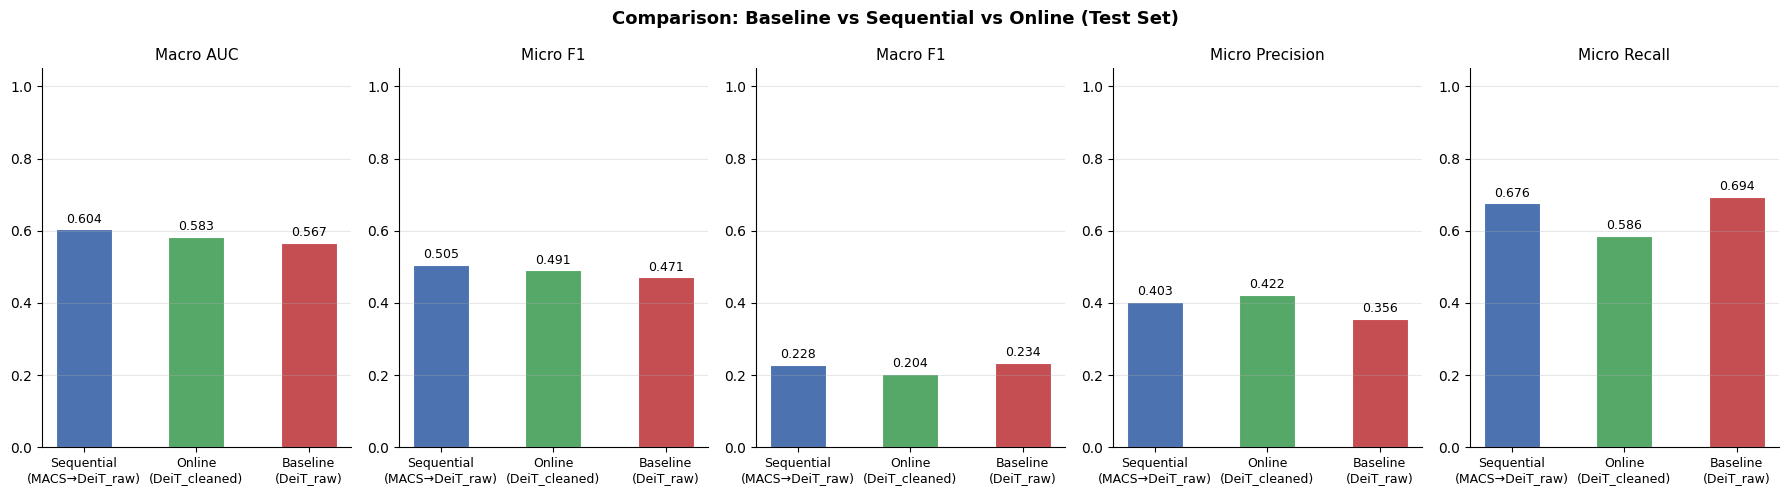

Saved: /content/drive/MyDrive/SKM-TEA/cleaned_outputs/sequential_macs_deit_raw/reports/comparison_3configs.png


In [ ]:
test_compare_plot = compare_df[compare_df["split"]=="test"].copy()

metrics_to_plot = ["macro_auc", "micro_f1", "macro_f1", "micro_precision", "micro_recall"]
metric_labels   = ["Macro AUC", "Micro F1", "Macro F1", "Micro Precision", "Micro Recall"]
colors = ["#4C72B0", "#55A868", "#C44E52"]  # blue=sequential, green=online, red=baseline

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))
fig.suptitle("Comparison: Baseline vs Sequential vs Online (Test Set)", fontsize=13, fontweight="bold")

config_names = test_compare_plot["config"].tolist()
x = np.arange(len(config_names))
bar_colors = colors[:len(config_names)]

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    vals = test_compare_plot[metric].tolist()
    bars = ax.bar(x, vals, color=bar_colors, width=0.5, edgecolor="white", linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("\n", "\n") for c in config_names], fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plot_path = os.path.join(REPORT_DIR, "comparison_3configs.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

## Cell 17 — Per-category AUC (Sequential)

In [ ]:
per_cat = pd.DataFrame({
    "category_id":   category_ids,
    "category_name": [cat_id_to_name[c] for c in category_ids],
    "val_auc":  [val_aucs.get(c, np.nan)  for c in category_ids],
    "test_auc": [test_aucs.get(c, np.nan) for c in category_ids],
})
per_cat.to_csv(os.path.join(REPORT_DIR, "per_category_auc.csv"), index=False)
display(per_cat)

,category_id,category_name,val_auc,test_auc
0,1,Meniscal Tear (Myxoid),NaN,NaN
1,2,Meniscal Tear (Horizontal),0.628571,0.818182
2,3,Meniscal Tear (Radial),0.937500,0.363636
3,4,Meniscal Tear (Vertical/Longitudinal),0.774194,0.898990
4,5,Meniscal Tear (Oblique),0.596429,0.406250
5,6,Meniscal Tear (Complex),0.462963,0.733990
6,7,Meniscal Tear (Flap),0.593750,NaN
7,8,Meniscal Tear (Extrusion),0.870690,0.638889
8,9,Ligament Tear (Low-Grade Sprain),0.750000,0.464646
9,10,Ligament Tear (Moderate Grade Sprain or Mucoid...,0.534483,0.338235


## Cell 18 — Visualize: Raw → MACS → DeiT (single MRI)

Inference trực quan trên 1 study bất kỳ: thấy raw, cleaned, và prediction.

Example scan: MTR_005
Path: /content/drive/MyDrive/SKM-TEA/cleaned_outputs/nifti_raw/MTR_005/MTR_005_series00.nii.gz


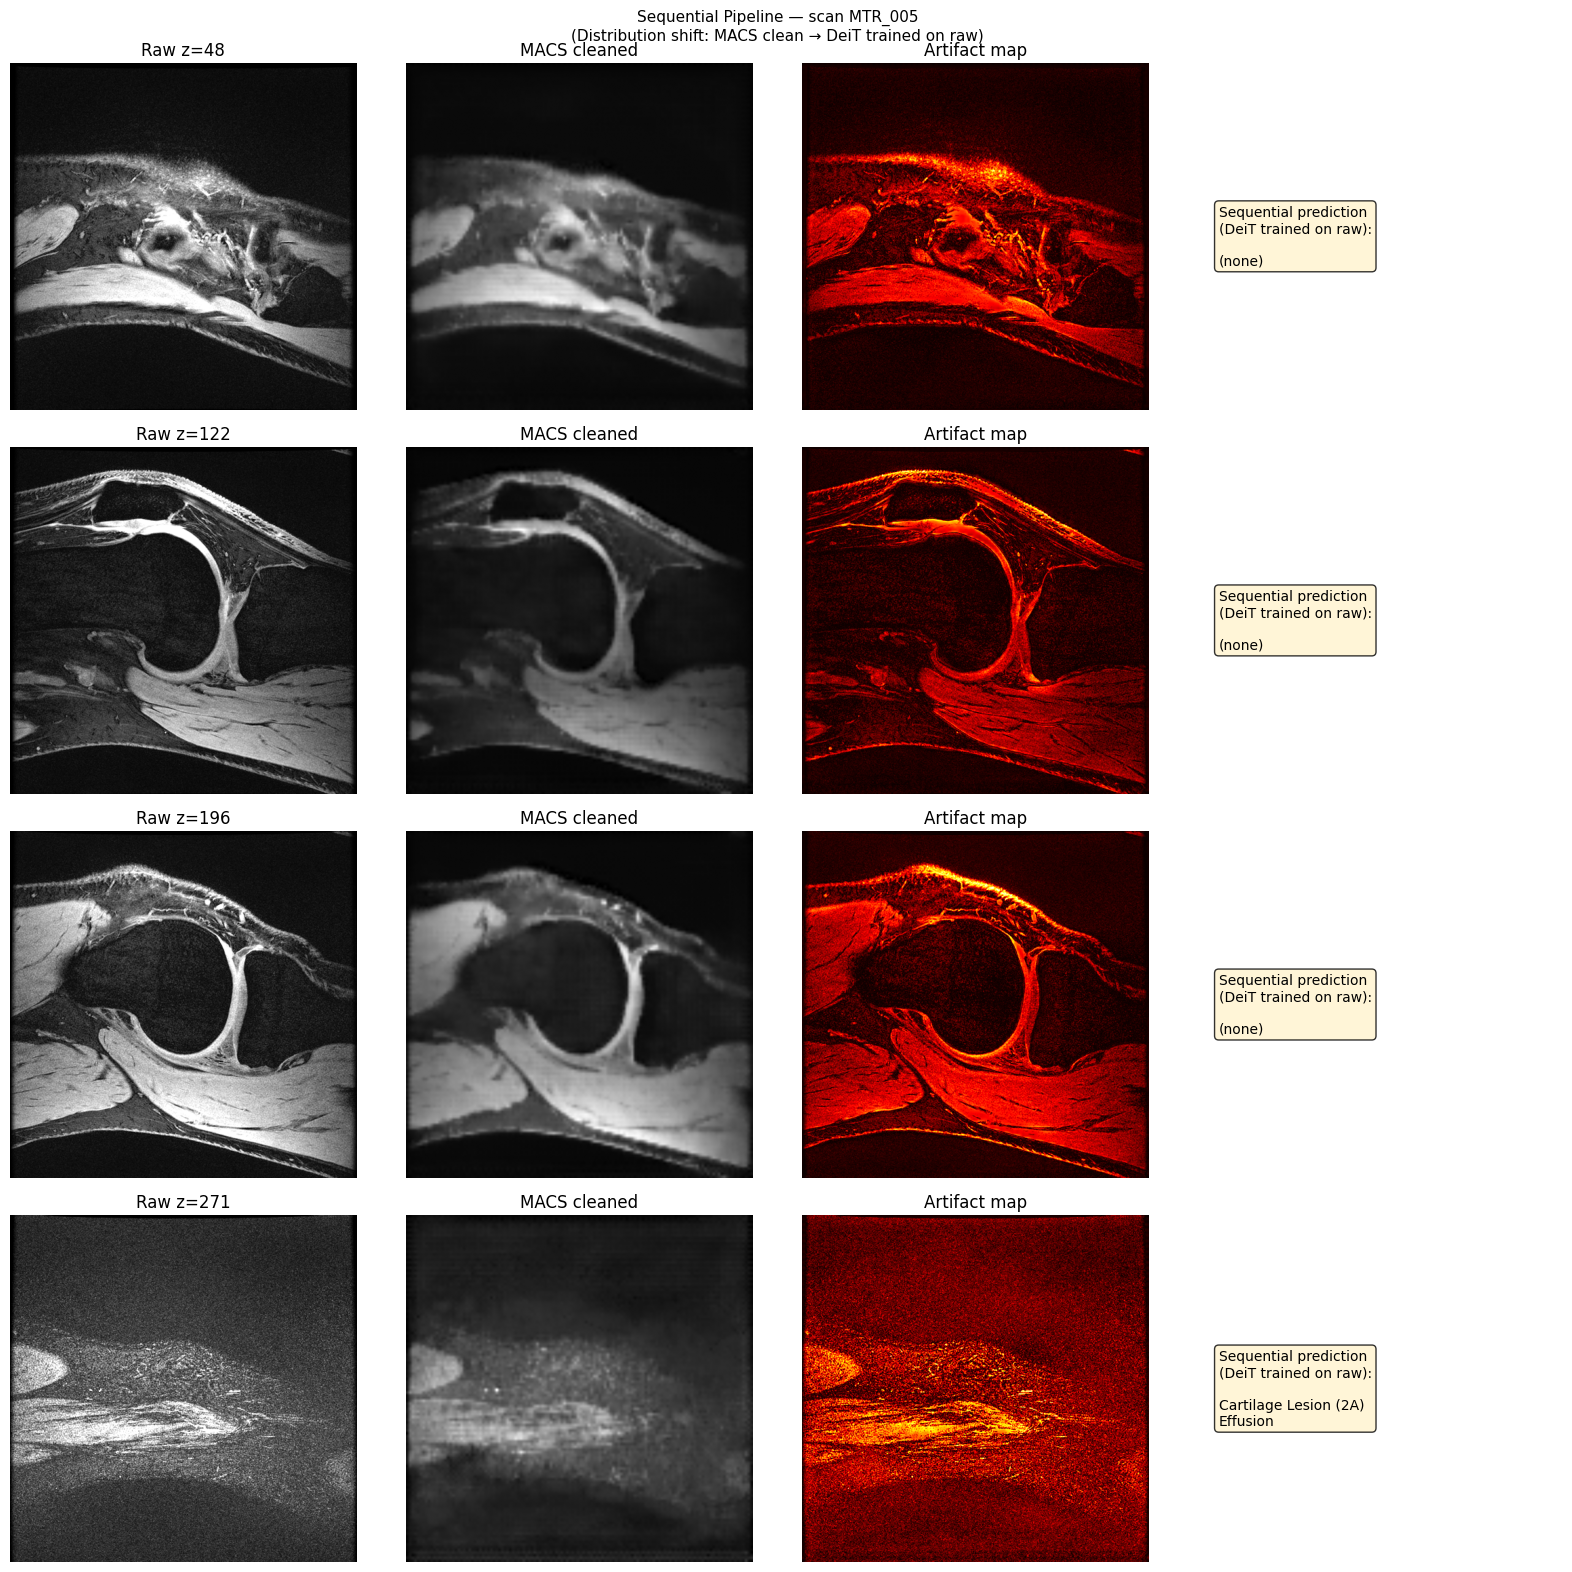

Saved: /content/drive/MyDrive/SKM-TEA/cleaned_outputs/sequential_macs_deit_raw/reports/sequential_visual_example.png


In [ ]:
example_row  = test_df.iloc[0]
example_path = example_row[image_col]
example_scan = example_row["scan_id"]
print("Example scan:", example_scan)
print("Path:", example_path)

vol_ex  = load_nifti_volume(example_path)
idxs_ex = sample_slice_indices(
    get_candidate_slice_indices(vol_ex, SLICE_START_FRAC, SLICE_END_FRAC, MIN_FOREGROUND_RATIO), 4)

fig, axes = plt.subplots(len(idxs_ex), 4, figsize=(16, 4*len(idxs_ex)))
if len(idxs_ex) == 1: axes = [axes]

deit_model.eval()
for ri, z_i in enumerate(idxs_ex):
    raw_s   = vol_ex[..., z_i].astype(np.float32)
    raw_n   = percentile_normalize(raw_s)
    clean_s = macs_clean_slice(raw_s)
    h, w    = raw_n.shape
    diff    = np.abs(raw_n - cv2.resize(clean_s, (w, h), interpolation=cv2.INTER_AREA))

    # DeiT inference on this slice (2.5D)
    depth = vol_ex.shape[-1]
    chs = []
    for zz in [max(0,z_i-1), z_i, min(depth-1,z_i+1)]:
        sl = macs_clean_slice(vol_ex[..., zz].astype(np.float32))
        chs.append(resize_2d(sl, DEIT_IMG_SIZE))
    x_tensor = torch.tensor(np.stack(chs, axis=0), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        with torch.amp.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
            logits = deit_model(x_tensor)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred_labels = [cat_id_to_name[cid] for cid, p in zip(category_ids, probs) if p >= BEST_THRESHOLD]
    pred_str = "\n".join(pred_labels) if pred_labels else "(none)"

    axes[ri][0].imshow(raw_n,   cmap="gray"); axes[ri][0].set_title(f"Raw z={z_i}")
    axes[ri][1].imshow(clean_s, cmap="gray"); axes[ri][1].set_title("MACS cleaned")
    axes[ri][2].imshow(diff,    cmap="hot");  axes[ri][2].set_title("Artifact map")
    axes[ri][3].axis("off")
    axes[ri][3].text(0.1, 0.5, f"Sequential prediction\n(DeiT trained on raw):\n\n{pred_str}",
                     transform=axes[ri][3].transAxes, fontsize=10, va="center",
                     bbox=dict(boxstyle="round", facecolor="#fff3cd", alpha=0.8))
    for ax in axes[ri][:3]: ax.axis("off")

plt.suptitle(f"Sequential Pipeline — scan {example_scan}\n"
             f"(Distribution shift: MACS clean → DeiT trained on raw)", fontsize=11)
plt.tight_layout()
vis_path = os.path.join(REPORT_DIR, "sequential_visual_example.png")
plt.savefig(vis_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", vis_path)

## Cell 19 — Inference trên 1 MRI bất kỳ (standalone)

Nhập đường dẫn file `.nii` hoặc `.nii.gz` bất kỳ để xem kết quả sequential pipeline.

In [ ]:
# ── Thay đổi đường dẫn này ────────────────────────────────────────────────────
SINGLE_MRI_PATH = "/content/drive/MyDrive/your_mri_file.nii.gz"
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def run_sequential_inference(nii_path: str, threshold: float = 0.5):
    """Chạy full sequential pipeline trên 1 MRI file.
    raw .nii/.nii.gz → MACS clean → DeiT (trained on raw) → predictions
    """
    print(f"Loading: {nii_path}")
    vol = load_nifti_volume(nii_path)
    print(f"Volume shape: {vol.shape}")

    # Lấy candidate slices
    idxs = sample_slice_indices(
        get_candidate_slice_indices(vol, SLICE_START_FRAC, SLICE_END_FRAC, MIN_FOREGROUND_RATIO),
        MAX_SAMPLES_PER_STUDY_EVAL)
    print(f"Processing {len(idxs)} slices: {idxs}")

    depth = vol.shape[-1]
    all_probs = []
    deit_model.eval()

    for z in tqdm(idxs, desc="Sequential inference"):
        chs = []
        for zz in [max(0,z-1), z, min(depth-1,z+1)]:
            sl = macs_clean_slice(vol[..., zz].astype(np.float32))
            chs.append(resize_2d(sl, DEIT_IMG_SIZE))
        x = torch.tensor(np.stack(chs, axis=0), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)
        with torch.amp.autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
            logits = deit_model(x)
        probs = torch.sigmoid(logits).squeeze().float().cpu().numpy()
        all_probs.append(probs)

    # Aggregate: max over slices (study-level)
    study_probs = np.stack(all_probs, axis=0).max(axis=0)

    # Output
    print(f"\n{'='*50}")
    print(f"SEQUENTIAL PIPELINE RESULT")
    print(f"File: {os.path.basename(nii_path)}")
    print(f"Threshold: {threshold:.2f}")
    print(f"{'='*50}")
    result_rows = []
    for cid, prob in zip(category_ids, study_probs):
        name = cat_id_to_name[cid]
        flag = "✓" if prob >= threshold else " "
        print(f"  [{flag}] {name:<30} {prob:.4f}")
        result_rows.append({"category": name, "probability": prob, "predicted": prob >= threshold})

    predicted = [r["category"] for r in result_rows if r["predicted"]]
    print(f"\nPredicted labels: {predicted if predicted else '(none)'}")
    return pd.DataFrame(result_rows)


if os.path.exists(SINGLE_MRI_PATH):
    result_df = run_sequential_inference(SINGLE_MRI_PATH, threshold=BEST_THRESHOLD)
    display(result_df)
else:
    print(f"⚠️  File không tồn tại: {SINGLE_MRI_PATH}")
    print("Cập nhật SINGLE_MRI_PATH ở đầu cell này.")

⚠️  File không tồn tại: /content/drive/MyDrive/your_mri_file.nii.gz
Cập nhật SINGLE_MRI_PATH ở đầu cell này.
